In [25]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict

In [26]:
# formation of the state
class BatsmanState(TypedDict):
    runs : int
    balls: int
    fours : int
    sixes : int
    
    sr : float
    bpb : float
    b_per : float
    summary : str
    

In [39]:
# making of functions
def calculate_sr(state: BatsmanState):
    
    sr = (state['runs']/state['balls'])*100
    return{'sr': sr}

In [40]:
def calculate_bpb(state: BatsmanState):
    
    bpb = state['balls']/(state['fours'] + state['sixes'])
    return {'bpb' : bpb}

In [41]:
def calculate_b_per(state:BatsmanState):
    
    b_per = (((state['fours']* 4) + (state['sixes'] * 6))/state['runs'])*100
    return {'b_per' : b_per}

In [42]:
def summary(state: BatsmanState):

    summary = f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['b_per']}
"""
    
    return {'summary': summary}

In [43]:
# graph forming
graph = StateGraph(BatsmanState)

# add node
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_b_per', calculate_b_per)
graph.add_node('summary', summary)

# add egdes
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_b_per')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_b_per', 'summary')

graph.add_edge('summary', END)
 
workflow = graph.compile()


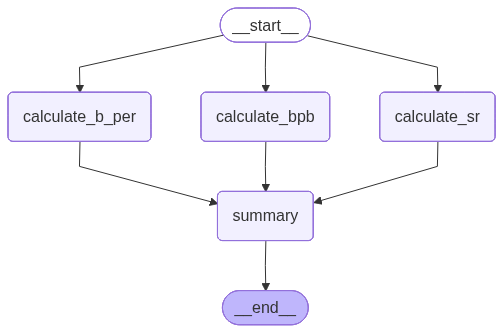

In [44]:
workflow

In [45]:
initial_state = {
    'runs' : 100,
    'balls' : 50,
    'fours' : 6,
    'sixes' : 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'b_per': 48.0,
 'summary': '\nStrike Rate - 200.0 \n\nBalls per boundary - 5.0 \n\nBoundary percent - 48.0\n'}